Esse Notebook será responsável por mostrar TODO meu passo a passo de evolução da acurácia, loss, quantas épocas e outras coisas 

# Primeiro teste foi feito com essa estrutura:

## Parâmetros utilizados

| Parâmetro | Valor |
|---|---:|
| Arquitetura | 784 → 128 → 64 → 10 |
| Camadas ocultas | 2 |
| Função de ativação | ReLU |
| Ativação da saída | Softmax |
| Função de erro | Cross-entropy loss |
| Otimizador | SGD |
| Learning rate | 0.1 |
| Batch size | 64 |
| Épocas | 10 |
| Seed | 42 |

## Interpretação da arquitetura

Cada imagem do MNIST possui 28 × 28 pixels. Após o reshape, cada imagem
é transformada em um vetor com 784 valores.

A arquitetura escolhida foi:

```text
784 entradas
    ↓
128 neurônios na primeira camada oculta
    ↓
64 neurônios na segunda camada oculta
    ↓
10 probabilidades de saída

```

As 10 saídas representam os dígitos possíveis entre 0 e 9.

## Resultados registrados

Os valores abaixo foram obtidos durante o treinamento do modelo
baseline.

Para cada época, foram armazenadas três informações:

- **Loss:** mede o tamanho do erro do modelo.
- **Acurácia de treino:** mede o desempenho nas imagens utilizadas
  durante o aprendizado.
- **Acurácia de teste:** mede o desempenho em imagens que não foram
  utilizadas para atualizar os pesos.

A acurácia de teste é especialmente importante porque mostra a
capacidade de generalização da rede neural.

In [ ]:
import matplotlib.pyplot as plt

epocas = [
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10
]

loss = [
    0.3300,
    0.1486,
    0.1068,
    0.0833,
    0.0680,
    0.0566,
    0.0472,
    0.0405,
    0.0340,
    0.0286
]

acuracia_treino = [
    94.43,
    96.23,
    97.43,
    98.02,
    98.34,
    98.61,
    98.79,
    98.47,
    99.13,
    99.52
]

acuracia_teste = [
    94.43,
    95.60,
    96.70,
    97.37,
    97.48,
    97.50,
    97.59,
    97.05,
    97.75,
    97.94
]

## Gráfico da Acurácia 

Nessa célula foi feito o gráfico de linha para entendermos como foi a evolução por época do primeiro teste e treino. Para termos uma noção, esse teste demorou 21 segundos. Depois vamos usar esse tempo e a acurácia para entendermos mais

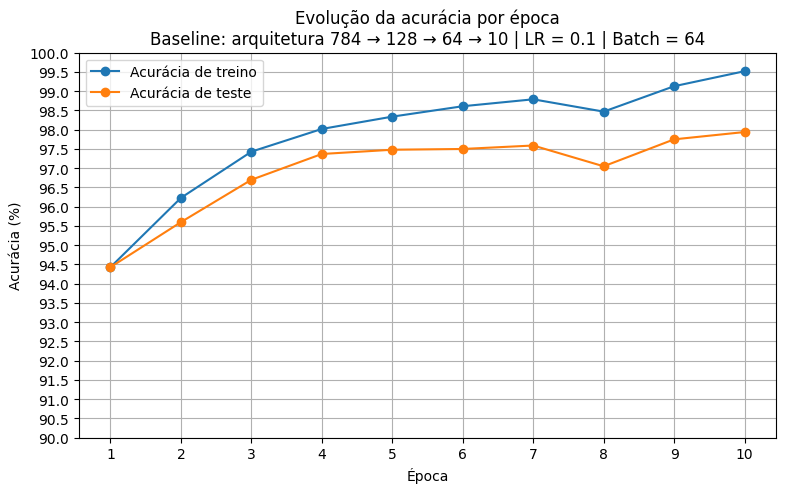

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    acuracia_treino,
    marker="o",
    label="Acurácia de treino"
)

plt.plot(
    epocas,
    acuracia_teste,
    marker="o",
    label="Acurácia de teste"
)

plt.title(
    "Evolução da acurácia por época\n"
    "Baseline: arquitetura 784 → 128 → 64 → 10 | LR = 0.1 | Batch = 64"
)

plt.xlabel("Época")
plt.ylabel("Acurácia (%)")

plt.xticks(epocas)

plt.ylim(90, 100)

plt.yticks(
    np.arange(90, 100.5, 0.5)
)

plt.grid(True)
plt.legend()

plt.savefig(
    "../results/baseline_acuracia_por_epoca.png",
    bbox_inches="tight"
)

plt.show()

## Gráfico de Loss

Aqui vamos mostrar a taxa de erro do nosso projeto e da primeira medição. Como é possível ver, deu uma bela despencada da primeira para a segunda época e depois vai estabilizando. Temos que diminuir mais essa linha e esse erro. Um jeito que vejo para isso é aumentarmos ou diminuirmos a taxa de aprendizado, que será nosso próximo passo.

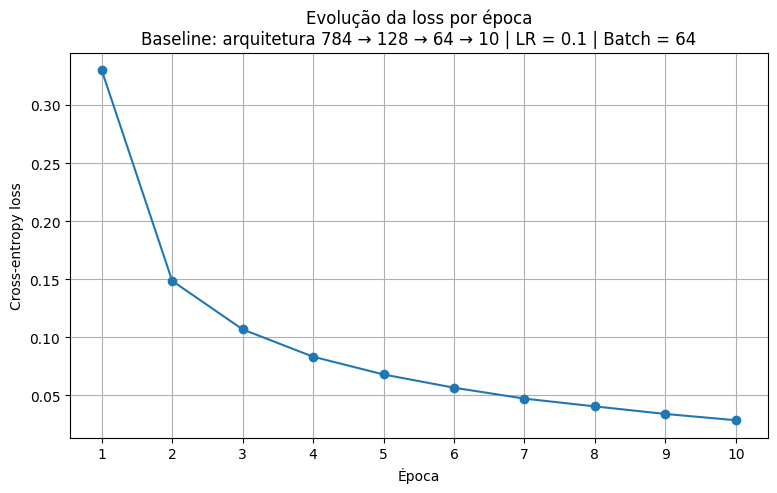

In [6]:
plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    loss,
    marker="o"
)

plt.title(
    "Evolução da loss por época\n"
    "Baseline: arquitetura 784 → 128 → 64 → 10 | LR = 0.1 | Batch = 64"
)

plt.xlabel("Época")
plt.ylabel("Cross-entropy loss")

plt.xticks(epocas)

plt.grid(True)

plt.savefig(
    "../results/baseline_loss_por_epoca.png",
    bbox_inches="tight"
)

plt.show()

## Conclusão 1

O modelo baseline apresentou uma evolução consistente durante o
treinamento.

A loss caiu de **0,3300** na primeira época para **0,0286** na décima
época. Isso indica que os ajustes realizados pelo SGD permitiram à rede
produzir previsões progressivamente mais próximas das respostas
corretas.

A acurácia de teste começou em **94,43%** e terminou em **97,94%**,
representando uma melhoria de **3,51 pontos percentuais**.

A maior acurácia de teste foi registrada na décima época: 97,94%

Houve também umas oscilações na oitava época: 
Época 7 → 97,59%
Época 8 → 97,05%
Época 9 → 97,75%

Isso é normal.


Os primeiros parâmetros foram colocados totalmente aleatórios. Para primeira vez, foi muito satisfatório. Mesmo passando de 92% de acurácia, quero deixar melhor e mais completo, tanto minha análise e testes como meu código e meu projeto. Como dito agora pouco, o primeiro parâmetro que vamos mexer é o de aprendizado.